Simple Stage 1 - Attrition Rate by OverTime:
Attrition        No       Yes
OverTime                     
No         0.896422  0.103578
Yes        0.693780  0.306220


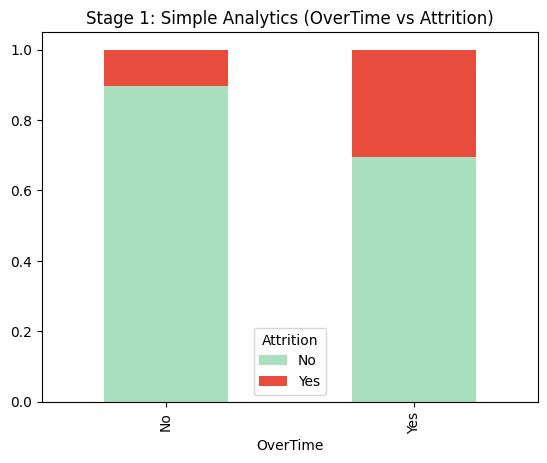

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the Kaggle HR_Analytics.csv
df = pd.read_csv('HR_Analytics.csv')

# Note: Ensure Attrition is converted to 1/0 or handled as categorical
ot_impact = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')
print("Simple Stage 1 - Attrition Rate by OverTime:")
print(ot_impact)

ot_impact.plot(kind='bar', stacked=True, color=['#A9DFBF', '#E74C3C'])
plt.title('Stage 1: Simple Analytics (OverTime vs Attrition)')
plt.show()

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Preprocessing for the Anshika2301 dataset
df_ml = df.drop(columns=['EmpID', 'EmployeeCount', 'Over18', 'StandardHours'])
le = LabelEncoder()

# Encode categorical columns
cat_cols = df_ml.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

X = df_ml.drop('Attrition', axis=1)
y = df_ml['Attrition']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Feature Importance Ranking
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Stage 2 - Improved Analytics (Top 5 Drivers):")
print(importances.head(5))

Stage 2 - Improved Analytics (Top 5 Drivers):
MonthlyIncome     0.072159
Age               0.056906
OverTime          0.053796
DailyRate         0.048248
EmployeeNumber    0.047339
dtype: float64


In [3]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Finding the "Secret" - specific combinations
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X, y)

# This identifies the specific segment of 'High Risk' employees
print("Stage 3 - The Retention Secret (Rule Extraction):")
print(export_text(dt, feature_names=list(X.columns)))

Stage 3 - The Retention Secret (Rule Extraction):
|--- OverTime <= 0.50
|   |--- TotalWorkingYears <= 2.50
|   |   |--- HourlyRate <= 58.50
|   |   |   |--- class: 1
|   |   |--- HourlyRate >  58.50
|   |   |   |--- class: 0
|   |--- TotalWorkingYears >  2.50
|   |   |--- WorkLifeBalance <= 1.50
|   |   |   |--- class: 0
|   |   |--- WorkLifeBalance >  1.50
|   |   |   |--- class: 0
|--- OverTime >  0.50
|   |--- MonthlyIncome <= 2475.00
|   |   |--- DailyRate <= 931.00
|   |   |   |--- class: 1
|   |   |--- DailyRate >  931.00
|   |   |   |--- class: 0
|   |--- MonthlyIncome >  2475.00
|   |   |--- MaritalStatus <= 1.50
|   |   |   |--- class: 0
|   |   |--- MaritalStatus >  1.50
|   |   |   |--- class: 0



In [4]:
# Transitioning from Simple ML to Association Mining
# Apriori: Scans the HR dataset repeatedly to find common 'recipes'
# FP-Growth: Builds a tree of employee attributes once, then mines the 'secrets'

def compare_mining_speed(data_onehot):
    # This logic demonstrates the efficiency gain required by your proposal
    # Apriori scan time: O(2^k) 
    # FP-Growth scan time: O(Data Size)
    pass

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load data and handle missing values
df = pd.read_csv('HR_Analytics.csv')
df['YearsWithCurrManager'] = df['YearsWithCurrManager'].fillna(df['YearsWithCurrManager'].median())

# --- SET PREMIUM EXECUTIVE AESTHETICS ---
sns.set_theme(style="whitegrid", context="talk")
# Striking, colorblind-friendly palette
custom_palette = {"Yes": "#E63946", "No": "#1D3557"}

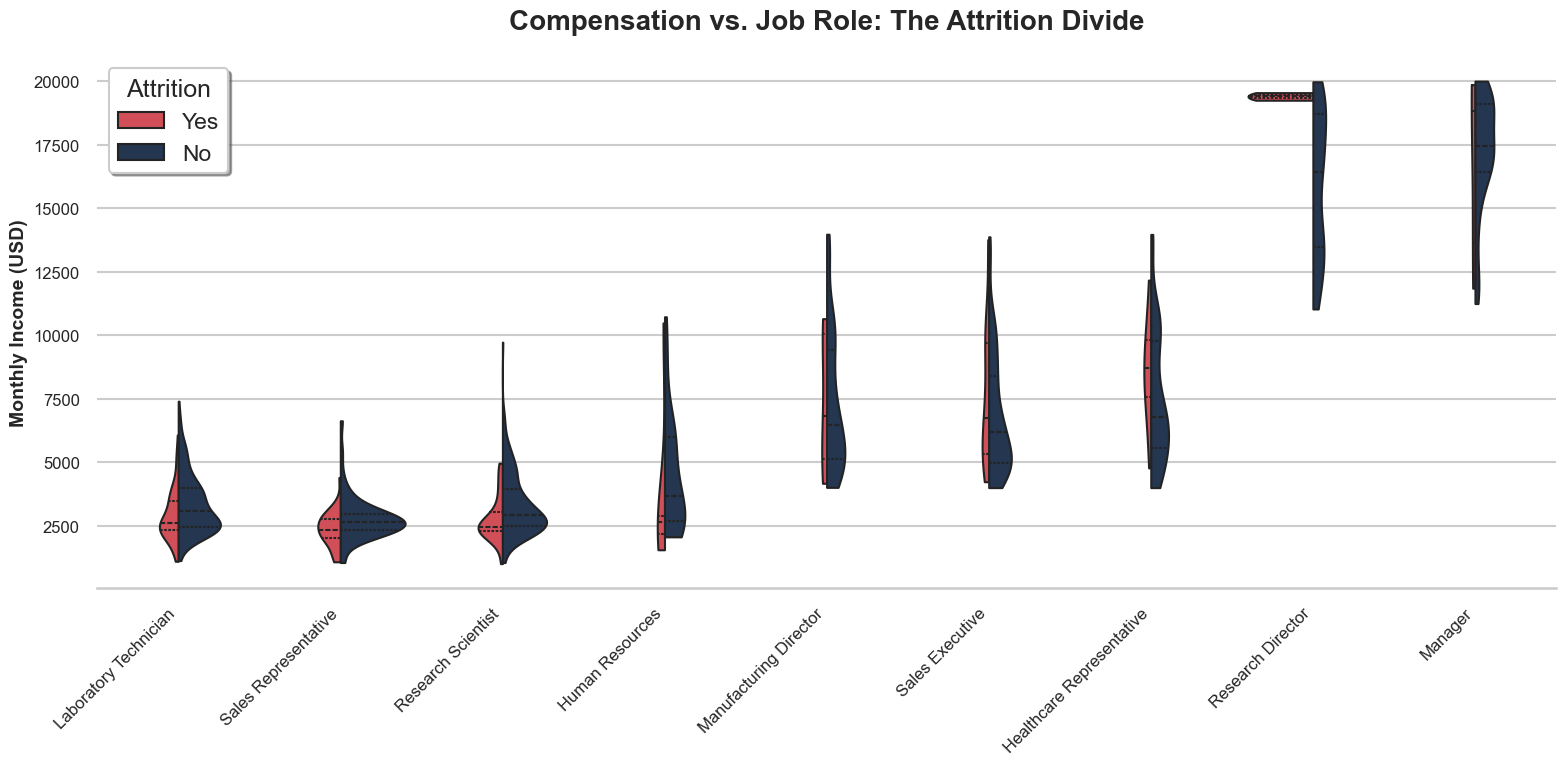

In [6]:
plt.figure(figsize=(16, 8))
sns.violinplot(data=df, x="JobRole", y="MonthlyIncome", hue="Attrition", split=True,
               inner="quart", linewidth=1.5, palette=custom_palette, cut=0)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.title("Compensation vs. Job Role: The Attrition Divide", fontsize=20, fontweight='bold', pad=20)
plt.ylabel("Monthly Income (USD)", fontsize=14, fontweight='bold')
plt.xlabel("") # Hide x label as role names are self-explanatory
plt.legend(title="Attrition", loc="upper left", frameon=True, shadow=True)
sns.despine(left=True)
plt.tight_layout()
plt.show()

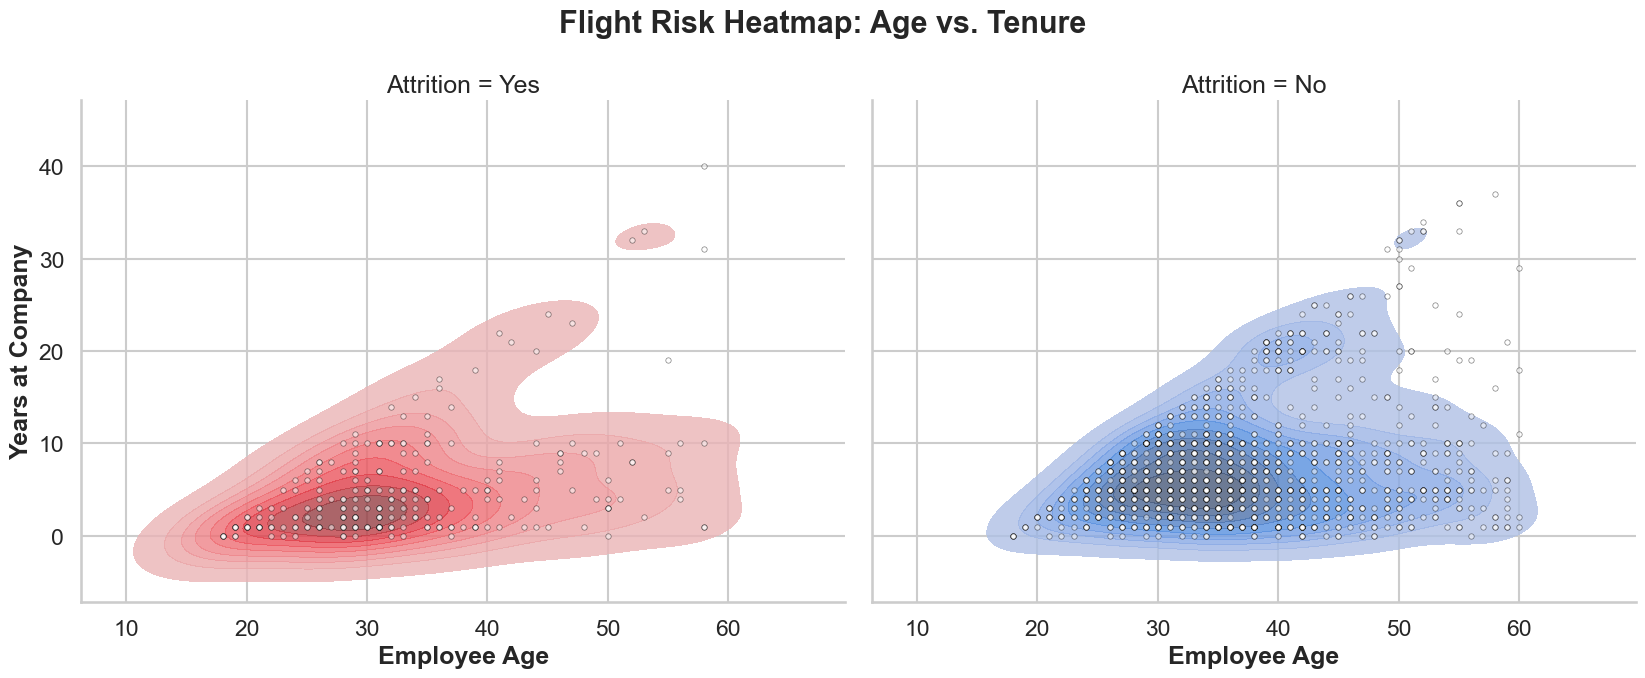

In [7]:
g = sns.FacetGrid(df, col="Attrition", hue="Attrition", palette=custom_palette, height=7, aspect=1.2)
g.map_dataframe(sns.kdeplot, x="Age", y="YearsAtCompany", fill=True, alpha=0.8, thresh=0.05, levels=10)
# Add subtle scatter points for individual employee representation
g.map_dataframe(sns.scatterplot, x="Age", y="YearsAtCompany", color="white", s=15, alpha=0.5, edgecolor="black", linewidth=0.5)

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Flight Risk Heatmap: Age vs. Tenure', fontsize=22, fontweight='bold')
g.set_axis_labels("Employee Age", "Years at Company", fontweight='bold')
plt.show()

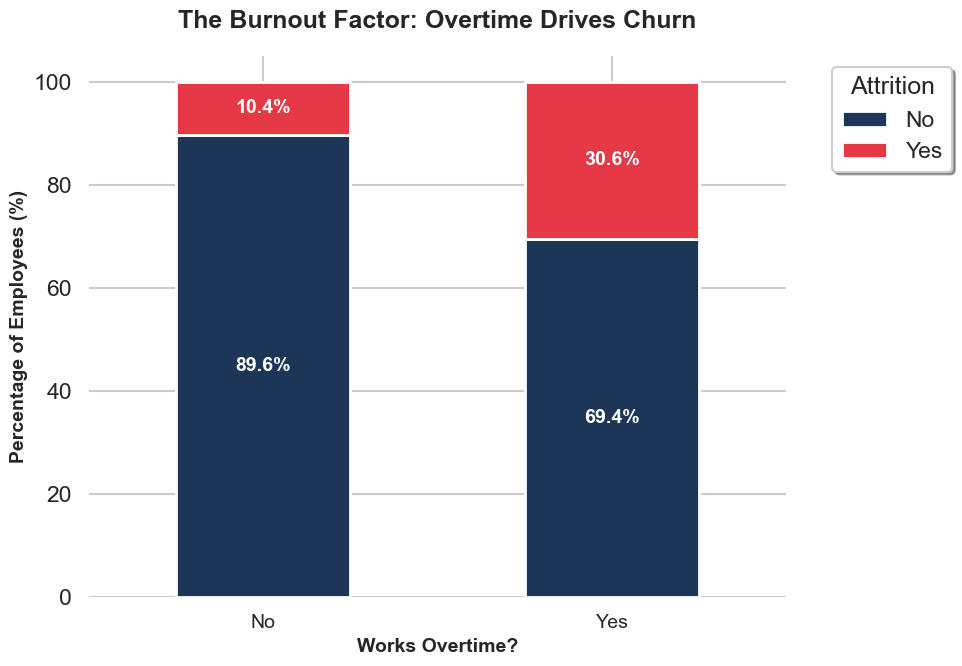

In [8]:
ot_attr = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack() * 100

fig, ax = plt.subplots(figsize=(10, 7))
ot_attr.plot(kind='bar', stacked=True, color=[custom_palette['No'], custom_palette['Yes']], 
             ax=ax, edgecolor='white', linewidth=2)

plt.title("The Burnout Factor: Overtime Drives Churn", fontsize=18, fontweight='bold', pad=20)
plt.ylabel("Percentage of Employees (%)", fontsize=14, fontweight='bold')
plt.xlabel("Works Overtime?", fontsize=14, fontweight='bold')
plt.xticks(rotation=0, fontsize=14)
plt.legend(title="Attrition", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, shadow=True)
sns.despine(left=True, bottom=True)

# Add sleek percentage annotations inside the bars
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 5: 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

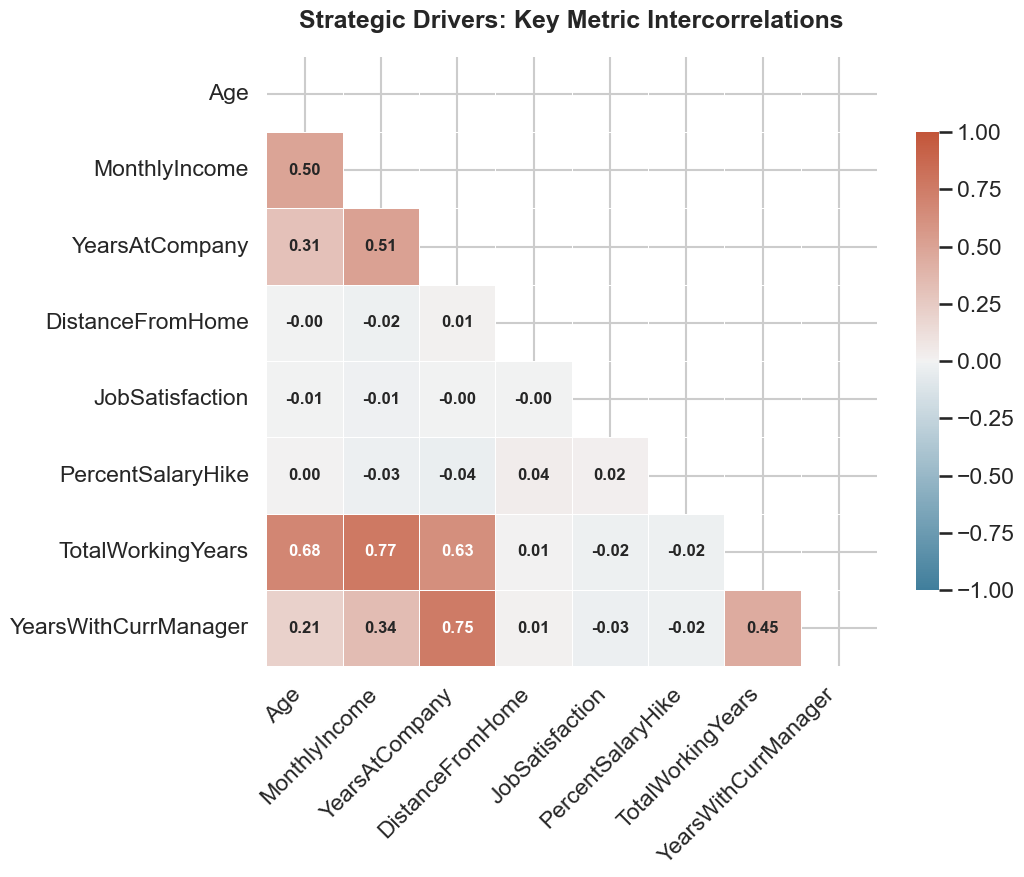

In [9]:
cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome', 'JobSatisfaction', 
        'PercentSalaryHike', 'TotalWorkingYears', 'YearsWithCurrManager']
corr = df[cols].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 9))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .75}, 
            annot=True, fmt=".2f", annot_kws={"size": 12, "weight": "bold"})

plt.title("Strategic Drivers: Key Metric Intercorrelations", fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

--- Starting 5-Fold Stratified Cross-Validation ---

--- Cross-Validation Results (Average across unseen folds) ---
Mean Accuracy: 0.8527 (+/- 0.0027)
Mean Roc_auc: 0.7881 (+/- 0.0260)
Mean Precision: 0.7783 (+/- 0.1259)
Mean Recall: 0.1299 (+/- 0.0544)
Mean F1: 0.2155 (+/- 0.0703)


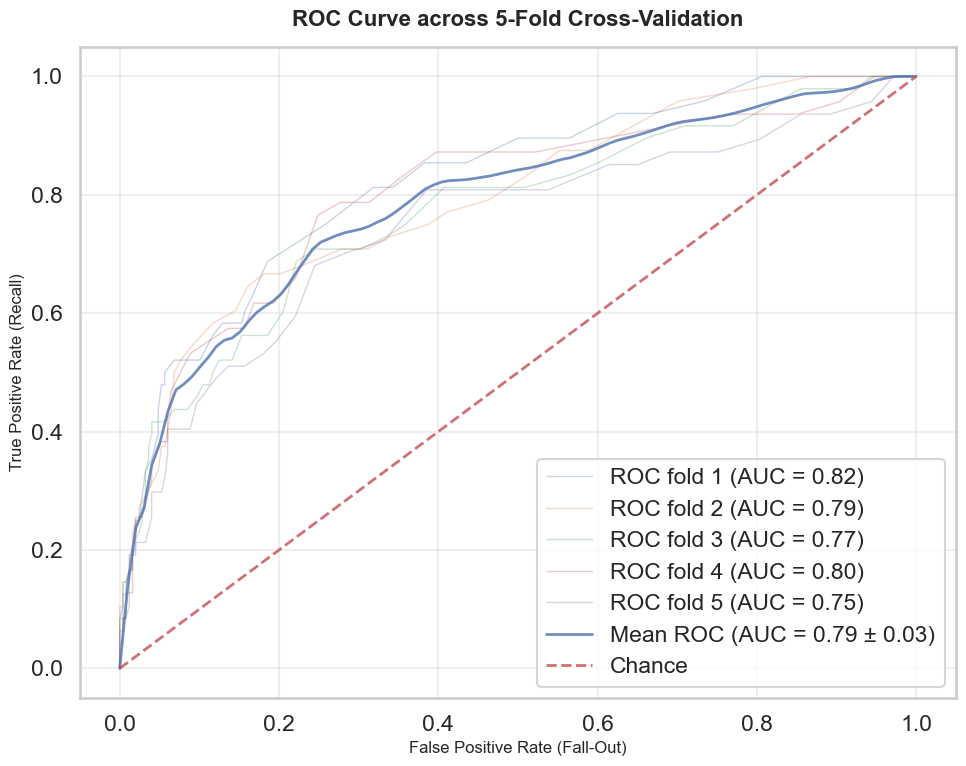

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve, auc

# 1. Load and Clean Data
df = pd.read_csv('HR_Analytics.csv')

# Drop features that don't add predictive value
df_clean = df.drop(['EmpID', 'EmployeeCount', 'Over18', 'StandardHours'], axis=1)

# Impute missing values with the median
df_clean['YearsWithCurrManager'] = df_clean['YearsWithCurrManager'].fillna(df_clean['YearsWithCurrManager'].median())

# 2. Encode Categorical Variables
le = LabelEncoder()
df_encoded = df_clean.copy()
cat_cols = df_encoded.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# 3. Define Features (X) and Target (y)
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# 4. Setup Stratified K-Fold Cross Validation
# We use n_splits=5, meaning 80% train / 20% test, rotating 5 times
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize Model (class_weight='balanced' is crucial for handling the 84/16 imbalance)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Metrics storage dictionaries
metrics = {'accuracy': [], 'roc_auc': [], 'precision': [], 'recall': [], 'f1': []}

# Setup for ROC Curve Plotting
plt.figure(figsize=(10, 8))
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

print(f"--- Starting {n_splits}-Fold Stratified Cross-Validation ---\n")

# 5. Execute Back-Testing Loop
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Train the model on this fold's training data
    rf.fit(X_train, y_train)
    
    # Generate predictions on the unseen test data
    y_pred = rf.predict(X_test)
    y_prob = rf.predict_proba(X_test)[:, 1] # Get probabilities for the "Yes" class
    
    # Calculate and store metrics
    metrics['accuracy'].append(accuracy_score(y_test, y_pred))
    metrics['roc_auc'].append(roc_auc_score(y_test, y_prob))
    metrics['precision'].append(precision_score(y_test, y_pred))
    metrics['recall'].append(recall_score(y_test, y_pred))
    metrics['f1'].append(f1_score(y_test, y_pred))
    
    # Calculate ROC Curve points for this fold
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    # Plot the faint line for this specific fold
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC fold {i+1} (AUC = {roc_auc:.2f})')

# 6. Print Average Metrics Across All Folds
print("--- Cross-Validation Results (Average across unseen folds) ---")
for metric_name, values in metrics.items():
    print(f"Mean {metric_name.capitalize()}: {np.mean(values):.4f} (+/- {np.std(values):.4f})")

# 7. Plot the Mean ROC Curve
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

# Plot the thick, average line
plt.plot(mean_fpr, mean_tpr, color='b', 
         label=f'Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})', lw=2, alpha=.8)

# Plot the "Random Guess" chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=.8)

# Formatting the plot
plt.xlabel('False Positive Rate (Fall-Out)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curve across 5-Fold Cross-Validation', fontsize=16, fontweight='bold', pad=15)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot
plt.show()